In [1]:
#Make sure you are in directory: Mori-Zwanzig-Autoencoder/
import os
os.chdir("../../")
print(os.getcwd())

/rds/general/user/pg221/home/PhD_projects/MZ-AE


In [2]:
import torch, pickle, os
from torch.utils.data import Dataset, DataLoader
from src.PreProc_Data.DataProc import StackedSequenceDataset
import numpy as np
from src.Eval_MZA import Eval_MZA
import matplotlib.pyplot as plt
import pandas as pd
import csv


# Numerical Experiment Directory

In [5]:
torch.cuda.empty_cache()
exp_dir = "Trained_Models/2DCyl/Case2"

models = []
exp_name_list = ["Koopman-AE",\
                 "MZ-AE_NRNN"
                 ]

for exp_name in exp_name_list:
    print(exp_name)
    models.append(Eval_MZA(exp_dir, exp_name))

Koopman-AE
########## Imp Info ##########
System:  ExpData
########## Imp Info ##########
System:  2DCyl
Training without Seqmodel
MZ-AE_NRNN
########## Imp Info ##########
System:  ExpData
########## Imp Info ##########
System:  2DCyl


# Plot Learning Curves

Epoch with Minimum train_error:  3654
Epoch with Minimum test_error:  3745


/rds/general/user/pg221/home/anaconda3/envs/MZ-AE-test/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


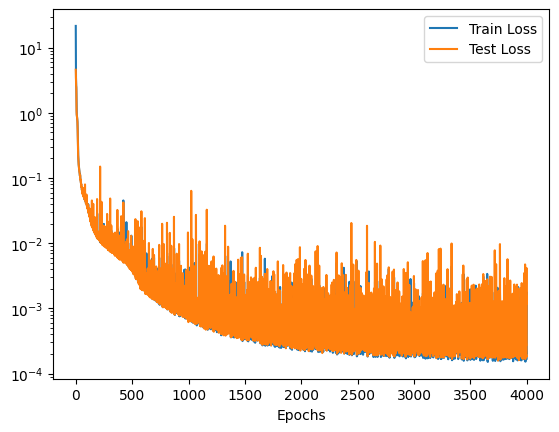

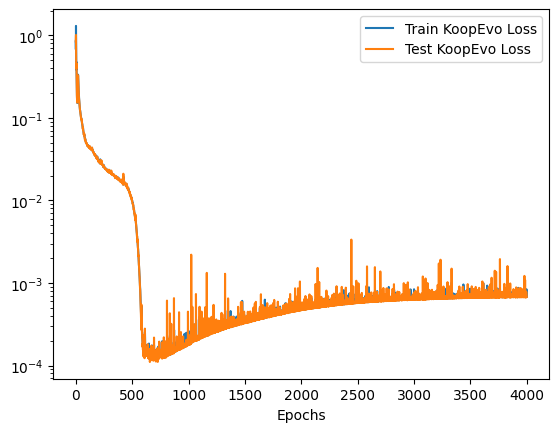

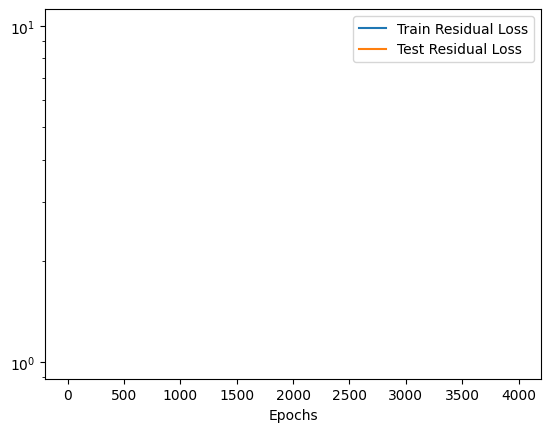

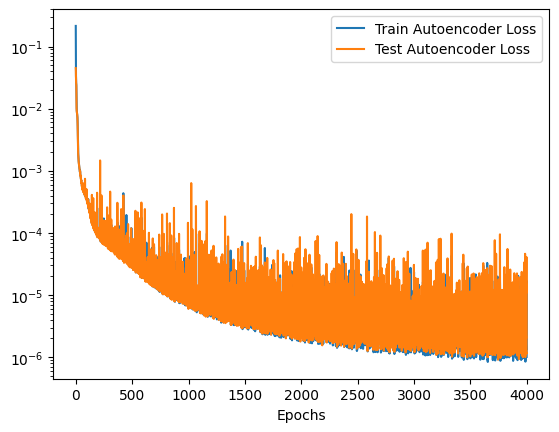

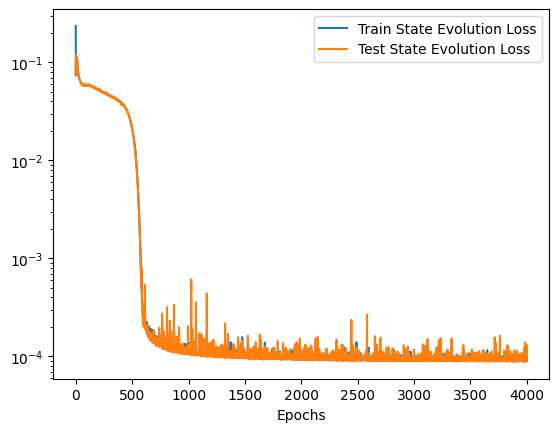

In [6]:
#plot learning curves
models[0].plot_learning_curves()

# Load Weights

In [7]:
# Transient Data with numobs5 only
for i in [0,1]:
    models[i].load_weights(other = True)

# Load Data

In [8]:
model_num = 0
models[model_num].load_and_preproc_data()
models[model_num].create_dataset(mode = "Test")
dataset = models[model_num].test_dataset
num_trajs = models[model_num].test_num_trajs

State Dims:  7938
Test_Shape:  (1, 1421, 7938)
Time:  6.7436158657073975


# Multi Step prediction

In [9]:
Phi_test = models[0].test_data
Phi_test = torch.from_numpy(Phi_test).to(torch.float32).to(models[0].device)

In [10]:
#multistep prediction
timesteps = 2000
initial_step = 0
initial_conditions = Phi_test[:,initial_step,:]

x_ms_hat, xkoop_ms_hat, xseq_ms_hat = [], [], []
Phi_ms_hat = torch.zeros((len(models),1,timesteps+1,models[0].statedim)).to(models[0].device)
Phi_ms_koop = torch.zeros((len(models),1,timesteps,models[0].statedim)).to(models[0].device)

print("ic shape:", initial_conditions.shape)

for i in range(len(models)):
    x_hat_temp, Phi_ms_hat[i], xkoop_hat_temp, xseq_hat_temp = models[i].predict_multistep(initial_conditions, timesteps)
    x_ms_hat.append(x_hat_temp)
    xkoop_ms_hat.append(xkoop_hat_temp)
    xseq_ms_hat.append(xseq_hat_temp)
print(Phi_ms_hat.shape)


ic shape: torch.Size([1, 7938])


/rds/general/user/pg221/home/anaconda3/envs/MZ-AE-test/lib/python3.9/site-packages/torch/nn/modules/rnn.py:878: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


torch.Size([2, 1, 2001, 7938])


In [11]:
#Predicted Velocity
U_ms_hat = Phi_ms_hat[...,:int(Phi_ms_hat.shape[-1]/2)].detach().cpu().numpy()
V_ms_hat = Phi_ms_hat[...,int(Phi_ms_hat.shape[-1]/2):].detach().cpu().numpy()

#DNS Velocity
U = Phi_test[...,:int(Phi_test.shape[-1]/2)].detach().cpu().numpy()
V = Phi_test[...,int(Phi_test.shape[-1]/2):].detach().cpu().numpy()

U_ms_hat.shape, V_ms_hat.shape, U.shape, V.shape

((2, 1, 2001, 3969), (2, 1, 2001, 3969), (1, 1421, 3969), (1, 1421, 3969))

(2, 1, 2001)


Text(0, 0.5, 'Kinetic Energy')

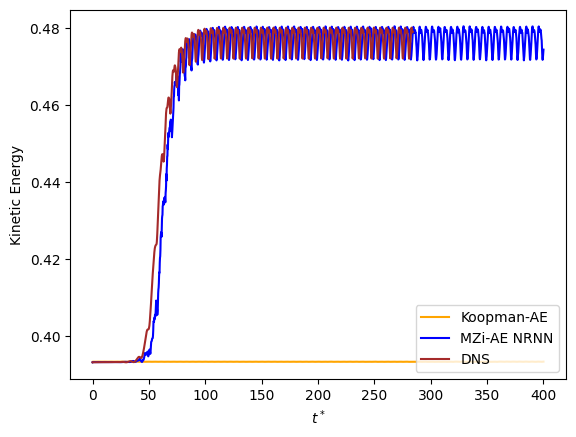

In [12]:
#calculating kinetic energy for multistep prediction 
def energy(u,v):
    k = 0.5*(np.mean(u**2,axis=-1) + np.mean(v**2,axis=-1))
    return k

k = energy(U, V)
k_ms_pred = energy(U_ms_hat, V_ms_hat)
print(k_ms_pred.shape)

plt.figure()
for i in [0,1]:
    if i==1:
        plt.plot(np.arange(k_ms_pred.shape[-1])*0.2,k_ms_pred[i,0,:], color = "blue" , label = f"MZi-AE NRNN")
    else:
        plt.plot(np.arange(k_ms_pred.shape[-1])*0.2,k_ms_pred[i,0,:], color = "orange", label = f"Koopman-AE")

plt.plot(np.arange(k[0,initial_step:].shape[-1])*0.2,k[0,initial_step:], label = "DNS",color = "brown")

plt.legend(loc='lower right')
plt.xlabel(r"$t^*$")
plt.ylabel("Kinetic Energy")

# Latent Evolution

Text(0, 0.5, '$\\xi_{2}$')

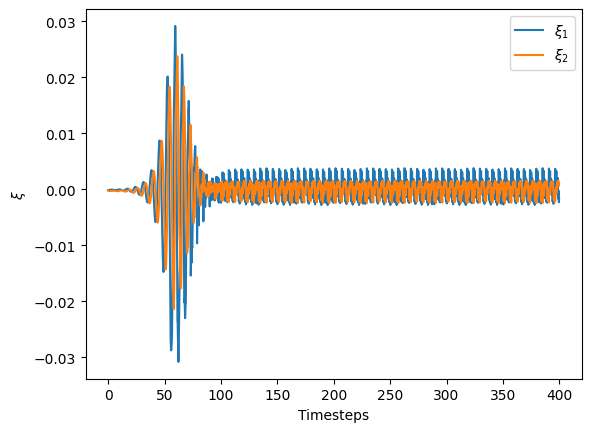

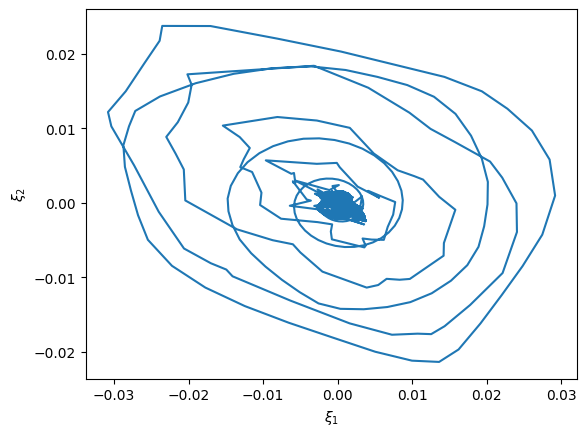

In [11]:
timesteps_latent = 2000
#plotting Memory evolution
plt.figure()
model_num = 1
tgt_xseq_ms_hat = xseq_ms_hat[model_num]
tgt_xkoop_ms_hat = xkoop_ms_hat[model_num]
for n in [0,1]:#range(models[model_num].num_obs):
    plt.plot(np.arange(timesteps_latent)*0.2,xseq_ms_hat[model_num][0,:timesteps_latent,n].cpu().numpy(), label = r"$\xi$"+f"$_{n+1}$")

plt.legend()
plt.xlabel("Timesteps")
plt.ylabel(r"$\xi$")

plt.figure()
plt.gca().set_aspect('equal')
plt.plot(xseq_ms_hat[model_num][0,:timesteps_latent,0].cpu().numpy(), xseq_ms_hat[model_num][0,:timesteps_latent,1].cpu().numpy())
plt.xlabel(r"$\xi_{1}$")
plt.ylabel(r"$\xi_{2}$")

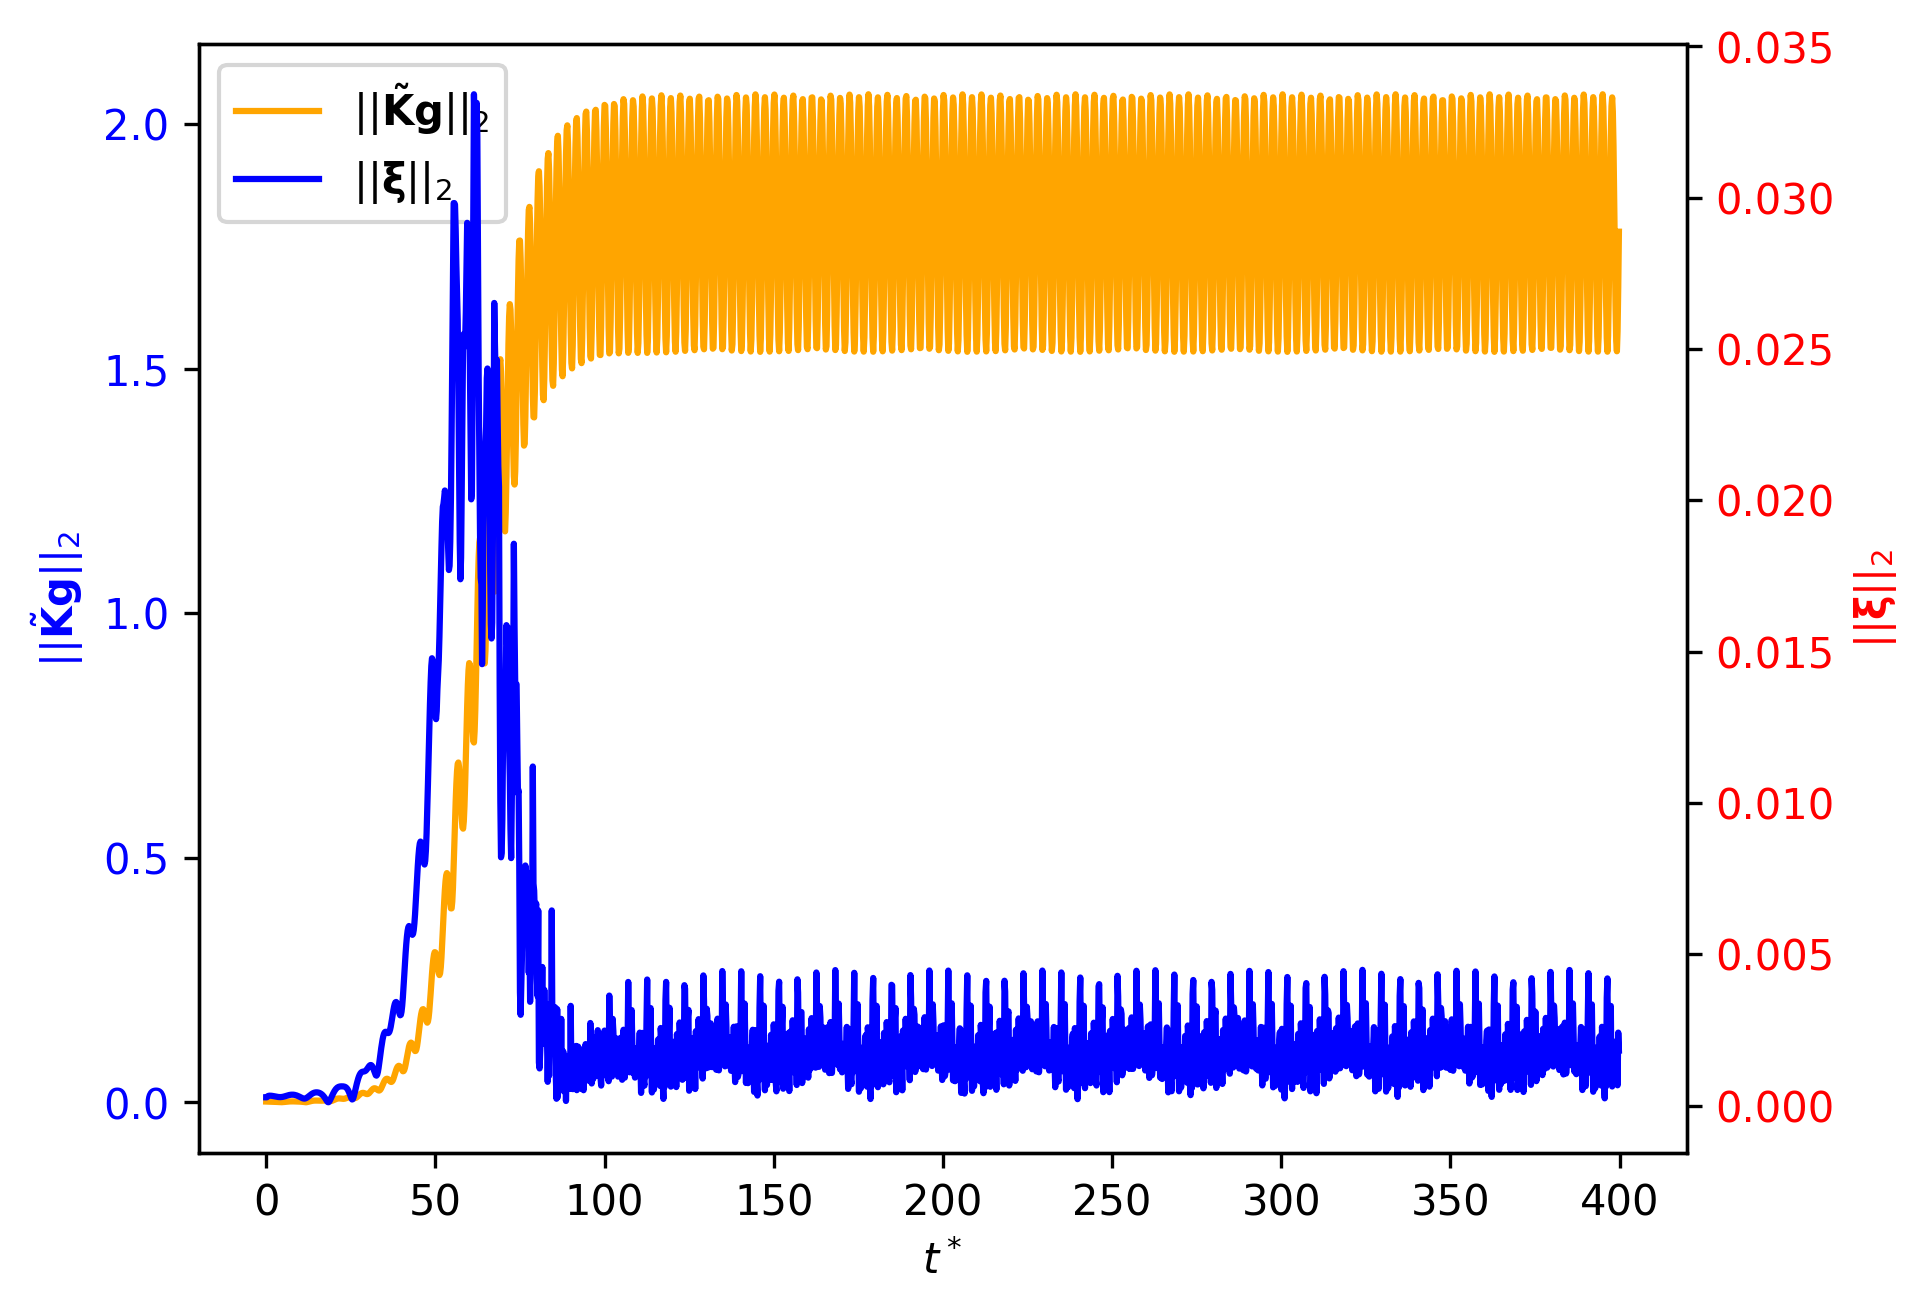

In [12]:
tgt_xseq_norm = np.linalg.norm(tgt_xseq_ms_hat, axis=-1)
tgt_xkoop_norm = np.linalg.norm(tgt_xkoop_ms_hat, axis=-1)

fig, ax1 = plt.subplots(dpi=300)
ax2 = ax1.twinx()

x = np.arange(timesteps_latent) * 0.2

ax1.plot(x, tgt_xkoop_norm[0, :timesteps_latent], color='orange', label=r"$||\tilde{\mathbf{K}}\mathbf{g}||_{2}$")
ax1.set_ylabel(r"$||\tilde{\mathbf{K}}\mathbf{g}||_{2}$", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.plot(x, tgt_xseq_norm[0, :timesteps_latent], color='blue', label=r"$||\mathbf{\xi}||_{2}$")
ax2.set_ylabel(r"$||\mathbf{\xi}||_{2}$", color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel(r"$t^*$")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')